In [56]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [57]:
import pandas as pd
import json
import matplotlib.pyplot as plt

In [58]:
weekly_dam_csv = "/home/dread/Documents/Personal projects/SA-Water-Dam-Level-Predictor/src/resources/all_dams_weekly.csv"
with open("/home/dread/Documents/Personal projects/SA-Water-Dam-Level-Predictor/src/resources/rainfall.json") as data:
    rain_data = json.load(data)

In [59]:
###RAINFALL JSON TO DATAFRAME###
rain_index = ["date", "water_level_mm"]
rain_df = pd.DataFrame(rain_data["data"])
rain_df.columns = rain_index
print(rain_df.info())
print(rain_df.describe())
print(rain_df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 9617 entries, 0 to 9616
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            9617 non-null   str    
 1   water_level_mm  9617 non-null   float64
dtypes: float64(1), str(1)
memory usage: 150.4 KB
None
       water_level_mm
count     9617.000000
mean         1.149207
std          1.597756
min          0.000000
25%          0.080735
50%          0.448099
75%          1.633875
max         19.466718
(9617, 2)


In [60]:
###SA DAM CSV TO DATAFRAME###
weekly_dam_df = pd.read_csv(weekly_dam_csv)
weekly_dam_df = weekly_dam_df.drop("Photo", axis=1)
print(weekly_dam_df.info())
print(weekly_dam_df.describe())
print(weekly_dam_df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   willDam     186 non-null    str    
 1   River       186 non-null    str    
 2   Indicators  186 non-null    str    
 3   FSC         186 non-null    float64
 4   This Week   186 non-null    str    
 5   Last Week   186 non-null    str    
 6   Last Year   186 non-null    str    
dtypes: float64(1), str(6)
memory usage: 10.3 KB
None
                FSC
count    186.000000
mean     272.719892
std     1282.877784
min        0.100000
25%        5.700000
50%       17.200000
75%       78.325000
max    15664.600000
(186, 7)


In [61]:
###RAIN DATA IN YEARS###
rain_df["date"] = pd.to_datetime(rain_df["date"])
rain_df["year"] = rain_df["date"].dt.year
rain_df['month'] = rain_df["date"].dt.month
rain_year_df = rain_df.groupby("year")["water_level_mm"].sum()
rain_month_df = rain_df.groupby("month")["water_level_mm"].mean()
print(rain_year_df.info())
print(rain_month_df.info())

<class 'pandas.Series'>
Index: 27 entries, 2000 to 2026
Series name: water_level_mm
Non-Null Count  Dtype  
--------------  -----  
27 non-null     float64
dtypes: float64(1)
memory usage: 324.0 bytes
None
<class 'pandas.Series'>
Index: 12 entries, 1 to 12
Series name: water_level_mm
Non-Null Count  Dtype  
--------------  -----  
12 non-null     float64
dtypes: float64(1)
memory usage: 144.0 bytes
None


In [62]:
###MAX YEAR RAIN DATA AND MIN YEAR DATA###
rain_year_maximum = rain_year_df.max()
rain_year_minimum = rain_year_df.min()
rain_year_max = rain_year_df.idxmax()
rain_year_min = rain_year_df.idxmin()

print(f"MAX IN YEAR: {rain_year_max} {rain_year_maximum}")
print(f"MIN IN YEAR: {rain_year_min} {rain_year_minimum}")

MAX IN YEAR: 2025 547.9358695004445
MIN IN YEAR: 2026 295.5616482434948


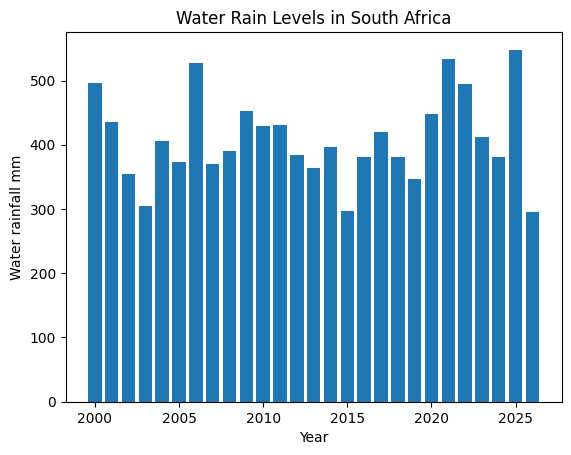

In [63]:
###YEAR RAIN GRAPH###
plt.bar(rain_year_df.index, rain_year_df.values)
plt.xlabel("Year")
plt.ylabel("Water rainfall mm")
plt.title("Water Rain Levels in South Africa")
plt.show()

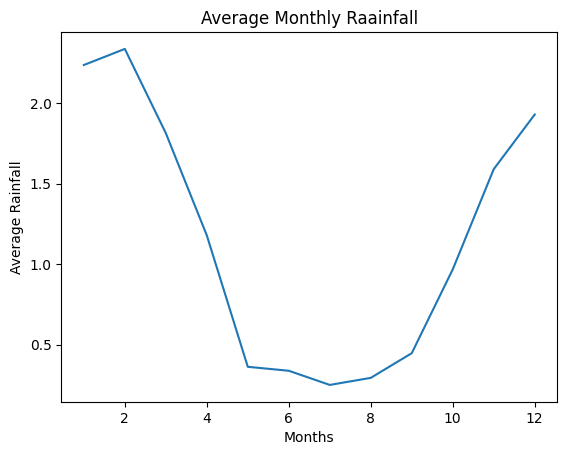

In [64]:
###Monthly Rainfall Average###
plt.plot(rain_month_df.index, rain_month_df.values)
plt.xlabel("Months")
plt.ylabel("Average Rainfall")
plt.title("Average Monthly Raainfall")
plt.show()

In [72]:
weekly_dam_df["This Week"] = weekly_dam_df["This Week"].astype(str).str.replace("#", "")
weekly_dam_df["This Week"] = pd.to_numeric(weekly_dam_df["This Week"])
print(weekly_dam_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   willDam     186 non-null    str    
 1   River       186 non-null    str    
 2   Indicators  186 non-null    str    
 3   FSC         186 non-null    float64
 4   This Week   186 non-null    float64
 5   Last Week   186 non-null    str    
 6   Last Year   186 non-null    str    
dtypes: float64(2), str(5)
memory usage: 10.3 KB
None


In [81]:
dams_under_50 = weekly_dam_df[weekly_dam_df["This Week"] < 50]
print(dams_under_50.info())
print(dams_under_50.count())
print(dams_under_50[["willDam", "This Week"]])
print(dams_under_50.describe())

<class 'pandas.DataFrame'>
Index: 6 entries, 92 to 165
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   willDam     6 non-null      str    
 1   River       6 non-null      str    
 2   Indicators  6 non-null      str    
 3   FSC         6 non-null      float64
 4   This Week   6 non-null      float64
 5   Last Week   6 non-null      str    
 6   Last Year   6 non-null      str    
dtypes: float64(2), str(5)
memory usage: 384.0 bytes
None
willDam       6
River         6
Indicators    6
FSC           6
This Week     6
Last Week     6
Last Year     6
dtype: int64
              willDam  This Week
92           Debe Dam       45.4
134       Leeubos Dam        0.0
140     Brandvlei Dam       45.7
142      Bulshoek Dam       46.6
163    Klipheuwel Dam       20.5
165  Kwaggaskloof Dam       45.1
              FSC  This Week
count    6.000000   6.000000
mean    78.733333  33.883333
std    121.223804  19.426726
min      1.000